<center><h1>Chavarkar_Rudrani_HW5</h1></center>
<br>
<br>

- Name: Rudrani Chavarkar
- GitHub Username: rudranichav
- USD ID: 3158-2107-65

## 1. Decision Trees as Interpretable Models

In [1]:
%pip install xgboost numpy pandas scikit-learn matplotlib seaborn

### Import packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, _tree
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline 
import warnings
warnings.filterwarnings('ignore')

print('All packages imported successfully.')

All packages imported successfully.


### (a) Obtain Data

The file uses semicolons, values are 'yes'/'no' and numeric temperature.
Columns: temperature, nausea, lumbar_pain, urine_pushing, micturition_pains, burning_urethra,
         inflammation (label1), nephritis (label2)

In [3]:
# Load the Acute Inflammations dataset

diag_cols = [
    'temperature', 'nausea', 'lumbar_pain', 'urine_pushing',
    'micturition_pains', 'burning_urethra',
    'inflammation_of_bladder', 'nephritis_of_renal_pelvis'
]

diag_df = pd.read_csv(
    '../data/diagnosis.data',
    header=None, names=diag_cols, sep='\t', engine="python", encoding="utf-16"
)

print("Initial data loaded:")
print("Shape:", diag_df.shape)
display(diag_df.head())

# Temperature uses comma as decimal separator in some locales
diag_df['temperature'] = diag_df['temperature'].str.replace(',', '.')

# Coerce numeric conversion; invalid parsing -> NaN
diag_df['temperature'] = pd.to_numeric(diag_df['temperature'], errors='coerce')

# Convert yes/no to 1/0 for other columns
for col in diag_df.columns:
    if col != 'temperature' and diag_df[col].dtype == object:
        diag_df[col] = diag_df[col].str.strip().map({'yes': 1, 'no': 0})

print("Data after cleaning:")
display(diag_df.head())

Initial data loaded:
Shape: (120, 8)


,temperature,nausea,lumbar_pain,urine_pushing,micturition_pains,burning_urethra,inflammation_of_bladder,nephritis_of_renal_pelvis
0,"35,5",no,yes,no,no,no,no,no
1,"35,9",no,no,yes,yes,yes,yes,no
2,"35,9",no,yes,no,no,no,no,no
3,"36,0",no,no,yes,yes,yes,yes,no
4,"36,0",no,yes,no,no,no,no,no


Data after cleaning:


,temperature,nausea,lumbar_pain,urine_pushing,micturition_pains,burning_urethra,inflammation_of_bladder,nephritis_of_renal_pelvis
0,35.5,0,1,0,0,0,0,0
1,35.9,0,0,1,1,1,1,0
2,35.9,0,1,0,0,0,0,0
3,36.0,0,0,1,1,1,1,0
4,36.0,0,1,0,0,0,0,0


### (b) Build a decision tree

Tree depth: 4
Number of leaves: 6


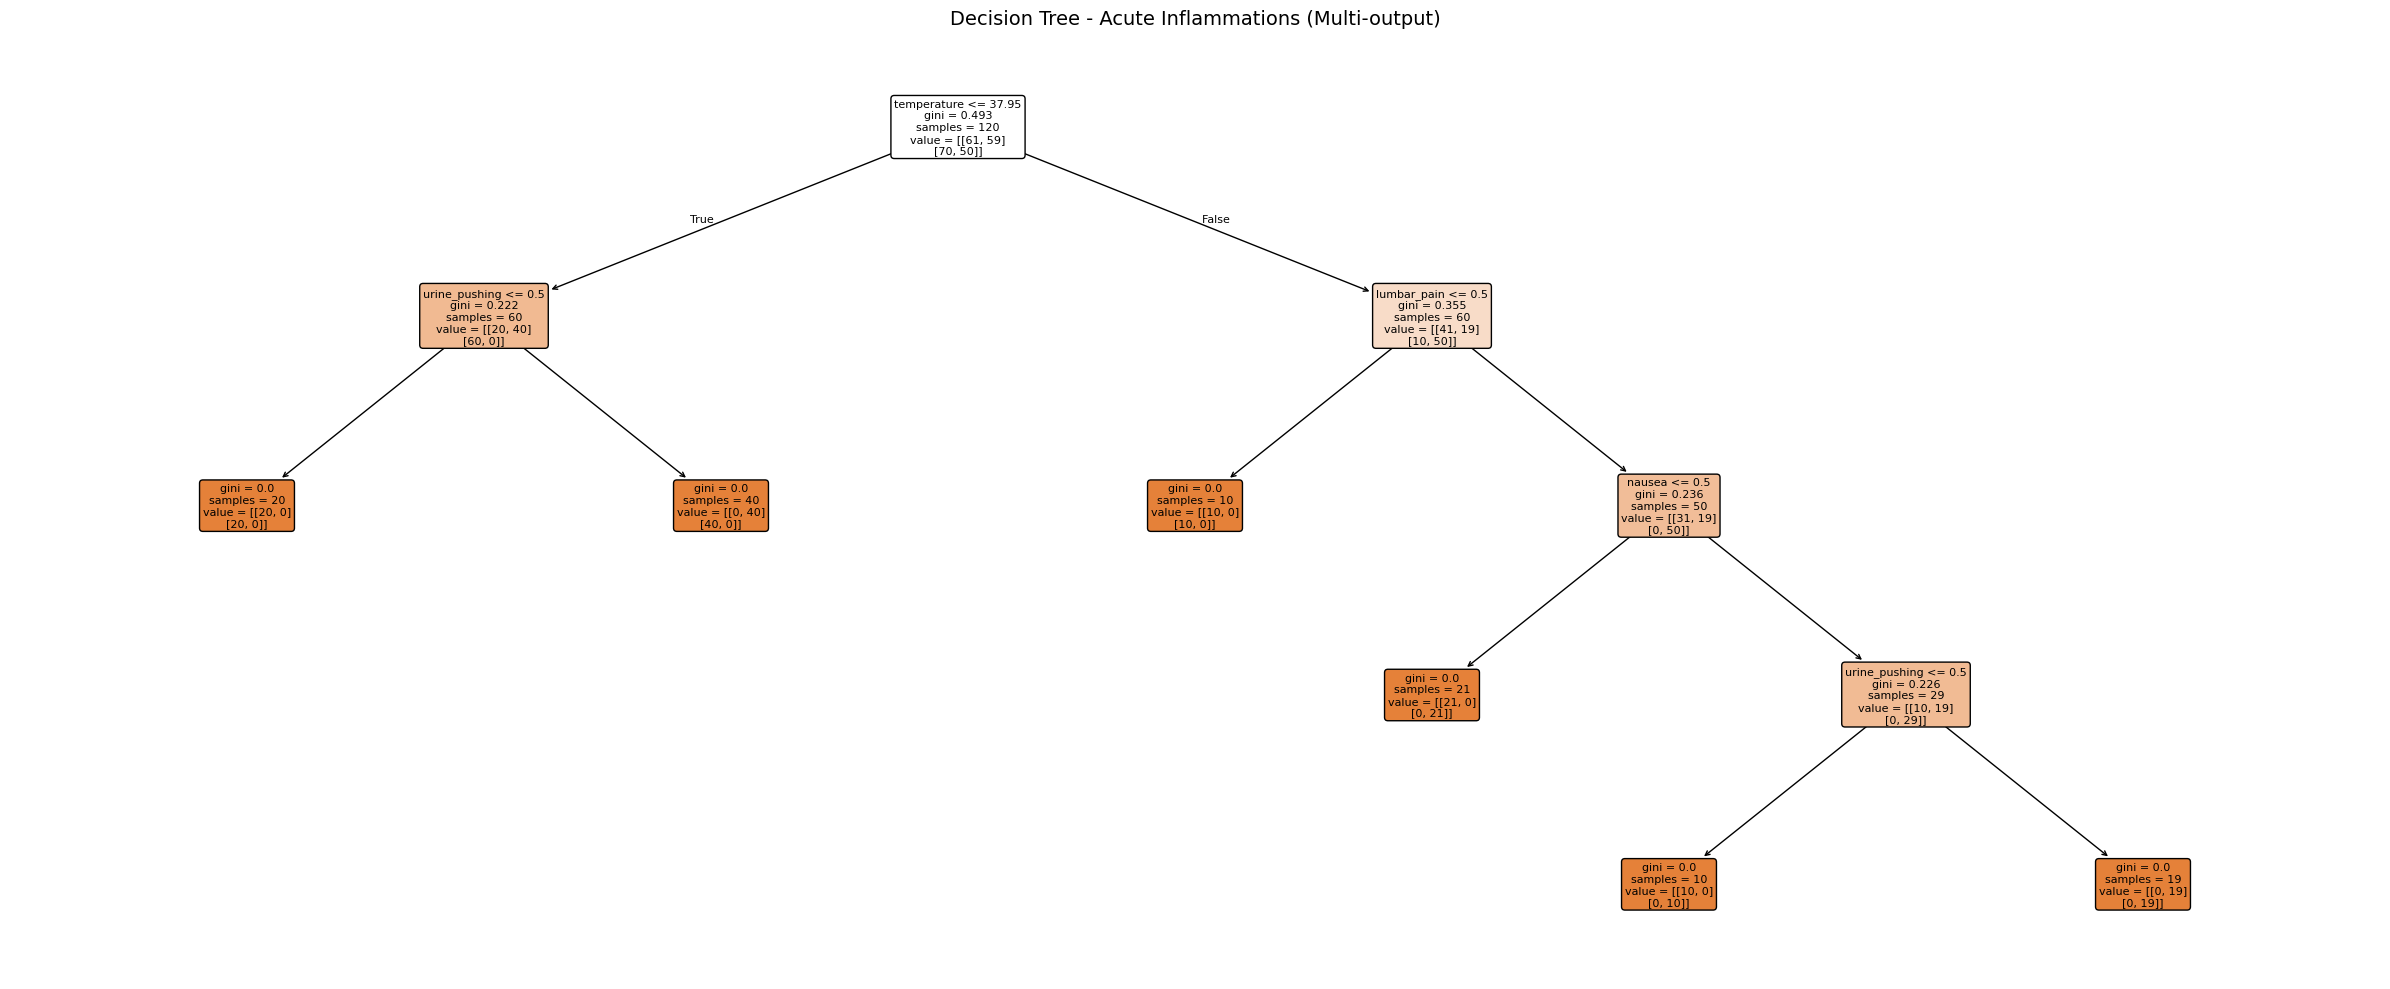

Tree plotted and saved.


In [4]:
# Features and multi-label targets
feature_cols = ['temperature', 'nausea', 'lumbar_pain', 'urine_pushing',
                'micturition_pains', 'burning_urethra']
label_cols = ['inflammation_of_bladder', 'nephritis_of_renal_pelvis']

X = diag_df[feature_cols].values
y = diag_df[label_cols].values  # multi-label

# Sklearn DecisionTreeClassifier supports multi-output natively
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X, y)

print(f'Tree depth: {dt.get_depth()}')
print(f'Number of leaves: {dt.get_n_leaves()}')

# Plot the tree
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['no', 'yes'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8
)
plt.title('Decision Tree - Acute Inflammations (Multi-output)', fontsize=14)
plt.tight_layout()
plt.show()
print('Tree plotted and saved.')

### (c) Convert the decision rules

In [5]:
# Extract IF-THEN rules using export_text
rules = export_text(dt, feature_names=feature_cols)
print('=== Decision Rules (IF-THEN format) ===')
print(rules)

=== Decision Rules (IF-THEN format) ===
|--- temperature <= 37.95
|   |--- urine_pushing <= 0.50
|   |   |--- class: 0
|   |--- urine_pushing >  0.50
|   |   |--- class: 1
|--- temperature >  37.95
|   |--- lumbar_pain <= 0.50
|   |   |--- class: 0
|   |--- lumbar_pain >  0.50
|   |   |--- nausea <= 0.50
|   |   |   |--- class: 0
|   |   |--- nausea >  0.50
|   |   |   |--- urine_pushing <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- urine_pushing >  0.50
|   |   |   |   |--- class: 0



In [6]:
# More readable IF-THEN rules using a recursive approach
# Recursively extract IF-THEN rules from a fitted decision tree.

def tree_to_rules(tree, feature_names, label_names=None):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else 'undefined!'
        for i in tree_.feature
    ]
    rules_list = []

    def recurse(node, depth, conditions):
        indent = '  ' * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            # Left branch: <= threshold
            recurse(tree_.children_left[node], depth + 1,
                    conditions + [f'{name} <= {threshold:.4f}'])
            # Right branch: > threshold
            recurse(tree_.children_right[node], depth + 1,
                    conditions + [f'{name} > {threshold:.4f}'])
        else:
            # Leaf node
            values = tree_.value[node]  # shape: (n_outputs, n_classes)
            prediction = []
            for output_idx, val in enumerate(values):
                class_idx = np.argmax(val)
                label = label_names[output_idx] if label_names else f'output_{output_idx}'
                pred_class = ['no', 'yes'][class_idx] if len(val) == 2 else str(class_idx)
                prediction.append(f'{label}={pred_class}')
            pred_str = ', '.join(prediction)
            if conditions:
                rule = 'IF ' + ' AND\n   '.join(conditions) + f'\n   THEN {pred_str}'
            else:
                rule = f'THEN {pred_str}  (root leaf)'
            rules_list.append(rule)

    recurse(0, 0, [])
    return rules_list

rules_list = tree_to_rules(dt, feature_cols, label_cols)
print(f'Total rules: {len(rules_list)}\n')
for i, rule in enumerate(rules_list, 1):
    print(f'Rule {i}:')
    print(rule)
    print()

Total rules: 6

Rule 1:
IF temperature <= 37.9500 AND
   urine_pushing <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=no

Rule 2:
IF temperature <= 37.9500 AND
   urine_pushing > 0.5000
   THEN inflammation_of_bladder=yes, nephritis_of_renal_pelvis=no

Rule 3:
IF temperature > 37.9500 AND
   lumbar_pain <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=no

Rule 4:
IF temperature > 37.9500 AND
   lumbar_pain > 0.5000 AND
   nausea <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=yes

Rule 5:
IF temperature > 37.9500 AND
   lumbar_pain > 0.5000 AND
   nausea > 0.5000 AND
   urine_pushing <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=yes

Rule 6:
IF temperature > 37.9500 AND
   lumbar_pain > 0.5000 AND
   nausea > 0.5000 AND
   urine_pushing > 0.5000
   THEN inflammation_of_bladder=yes, nephritis_of_renal_pelvis=yes



### (d) Cost-complexity pruning for minimal decision tree

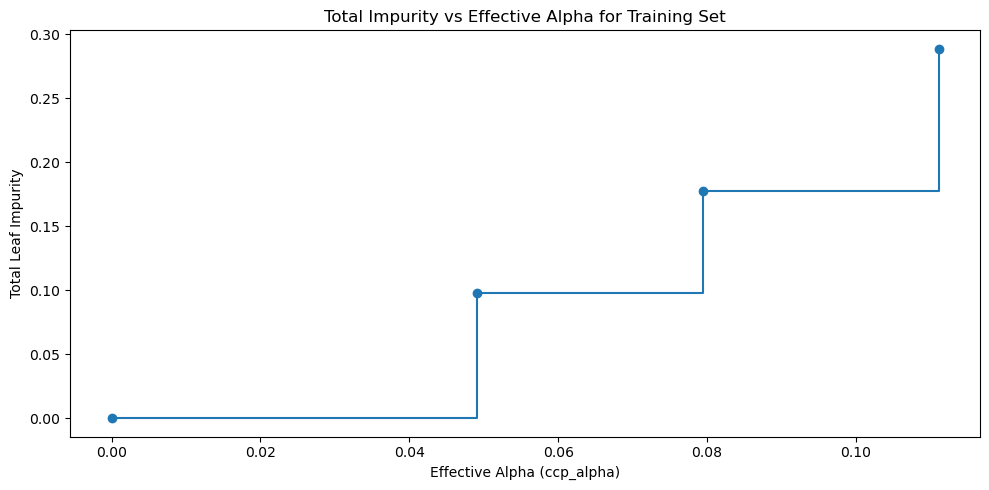

Best ccp_alpha: 0.000000
Pruned tree depth: 4
Pruned tree leaves: 6


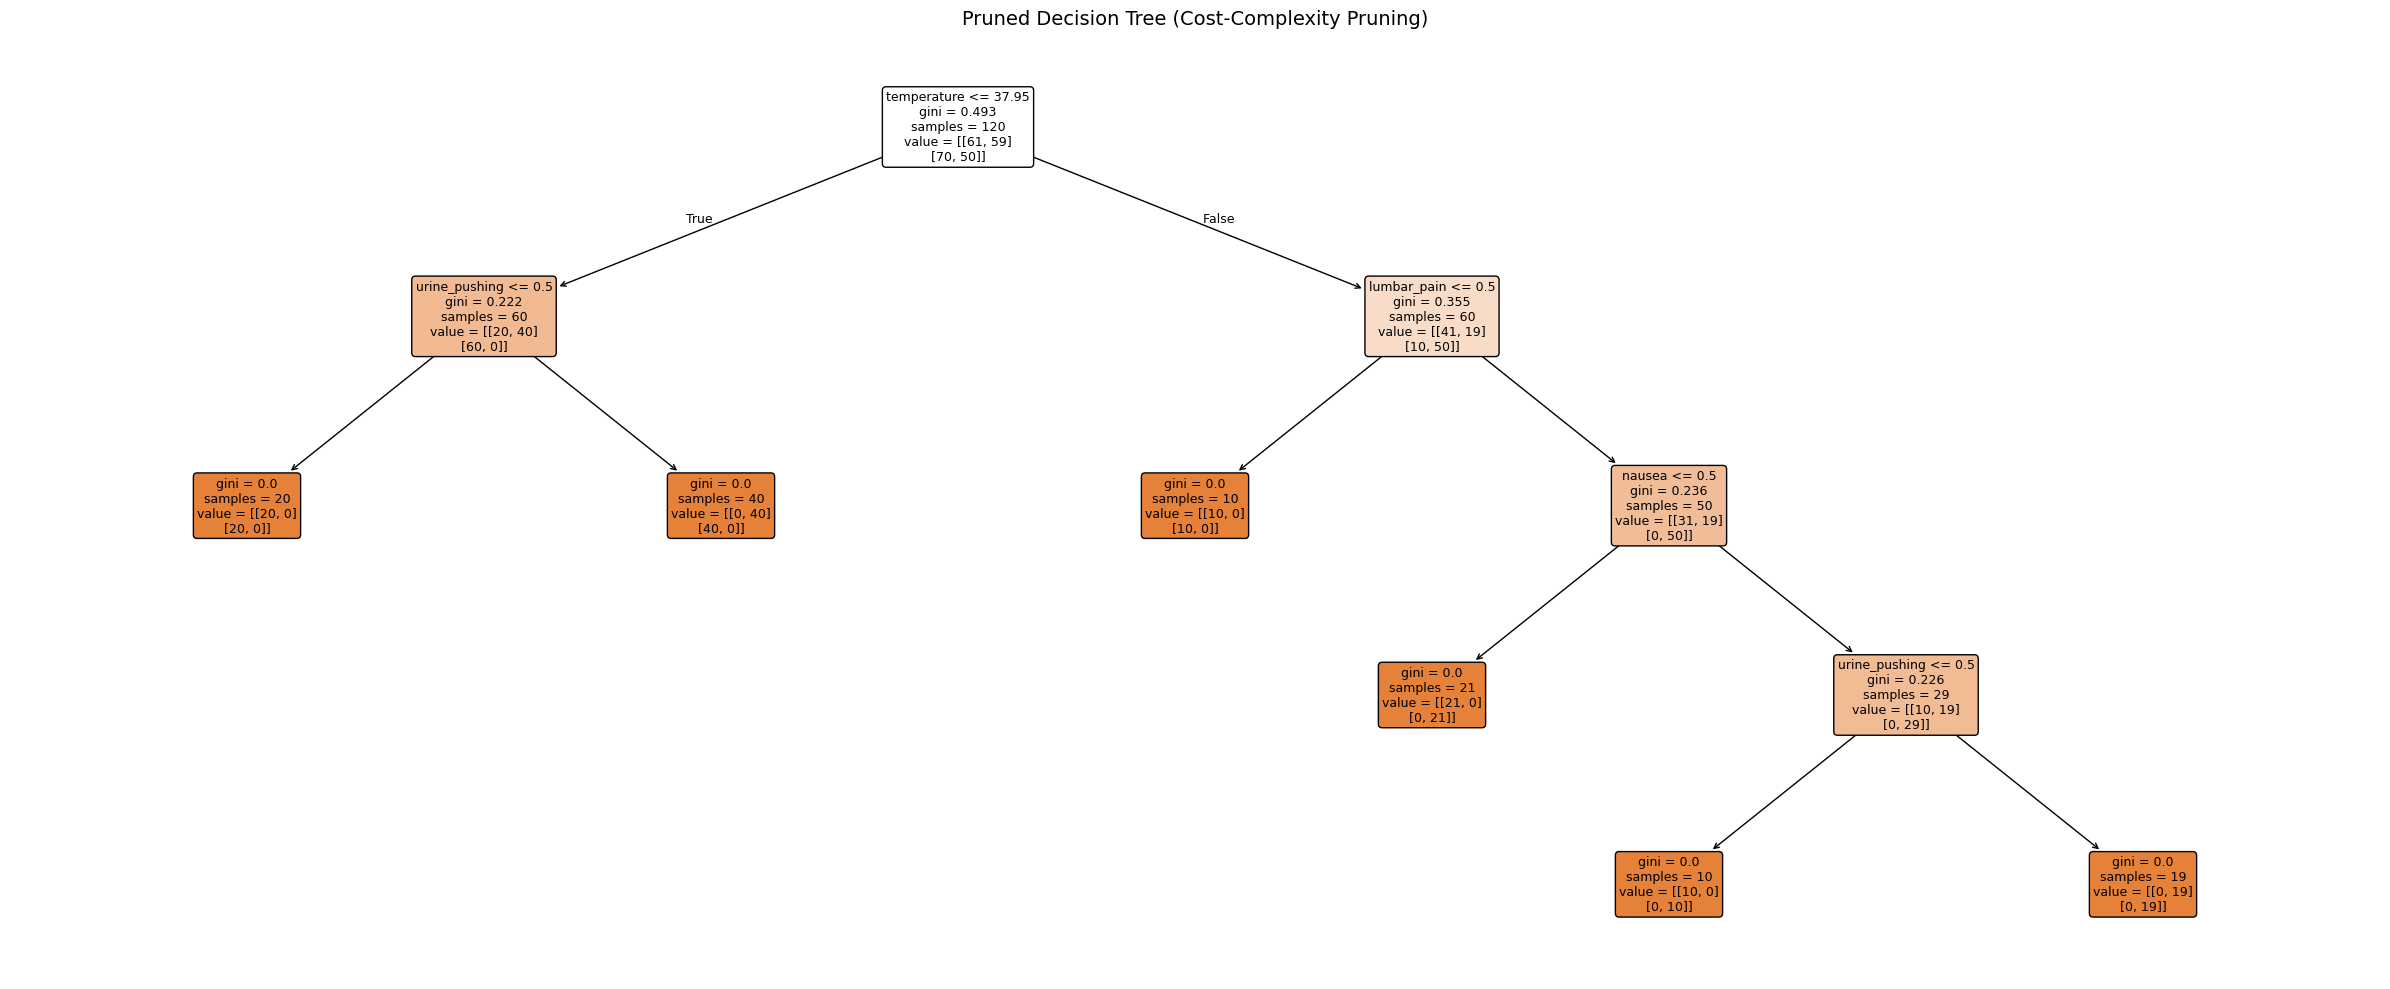


=== Pruned Tree Rules ===
Rule 1:
IF temperature <= 37.9500 AND
   urine_pushing <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=no

Rule 2:
IF temperature <= 37.9500 AND
   urine_pushing > 0.5000
   THEN inflammation_of_bladder=yes, nephritis_of_renal_pelvis=no

Rule 3:
IF temperature > 37.9500 AND
   lumbar_pain <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=no

Rule 4:
IF temperature > 37.9500 AND
   lumbar_pain > 0.5000 AND
   nausea <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=yes

Rule 5:
IF temperature > 37.9500 AND
   lumbar_pain > 0.5000 AND
   nausea > 0.5000 AND
   urine_pushing <= 0.5000
   THEN inflammation_of_bladder=no, nephritis_of_renal_pelvis=yes

Rule 6:
IF temperature > 37.9500 AND
   lumbar_pain > 0.5000 AND
   nausea > 0.5000 AND
   urine_pushing > 0.5000
   THEN inflammation_of_bladder=yes, nephritis_of_renal_pelvis=yes



In [7]:
# Find optimal alpha using cost-complexity pruning path
path = dt.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Plot impurity vs alpha
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle='steps-post')
ax.set_xlabel('Effective Alpha (ccp_alpha)')
ax.set_ylabel('Total Leaf Impurity')
ax.set_title('Total Impurity vs Effective Alpha for Training Set')
plt.tight_layout()
plt.show()

# Cross-validate to pick the best alpha
cv_scores = []
for alpha in ccp_alphas[:-1]:
    dt_cv = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(dt_cv, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_alpha = ccp_alphas[np.argmax(cv_scores)]
print(f'Best ccp_alpha: {best_alpha:.6f}')

# Build pruned tree
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_pruned.fit(X, y)
print(f'Pruned tree depth: {dt_pruned.get_depth()}')
print(f'Pruned tree leaves: {dt_pruned.get_n_leaves()}')

# Plot pruned tree
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_pruned,
    feature_names=feature_cols,
    class_names=['no', 'yes'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=9
)
plt.title('Pruned Decision Tree (Cost-Complexity Pruning)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_pruned.png', dpi=150, bbox_inches='tight')
plt.show()

# Print pruned rules
print('\n=== Pruned Tree Rules ===')
pruned_rules = tree_to_rules(dt_pruned, feature_cols, label_cols)
for i, rule in enumerate(pruned_rules, 1):
    print(f'Rule {i}:')
    print(rule)
    print()

### Pruning result

The cost-complexity path selected ccp_alpha = 0, so cross-validation did not find a simpler subtree that improved generalization over the original tree. In practical terms, this means the unpruned tree is already compact, and pruning does not buy much additional interpretability here.

## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [8]:
# Load Communities and Crime dataset
# The .names file indicates the first 5 columns are non-predictive
# Column 128 (index 127) is the target: ViolentCrimesPerPop

comm_df = pd.read_csv('../data/communities.data', header=None, na_values='?')
print('Raw shape:', comm_df.shape)

# First 5 columns are non-predictive (state, county, community, communityname, fold)
# Drop them
comm_df = comm_df.iloc[:, 5:]  # keep columns 5 onward (122 predictive + 1 target)
print('After removing non-predictive columns:', comm_df.shape)

# The last column is the target
target_col = comm_df.columns[-1]
feature_cols_comm = comm_df.columns[:-1].tolist()

# Split train/test: first 1495 rows as training
train_df = comm_df.iloc[:1495].copy()
test_df  = comm_df.iloc[1495:].copy()

print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

Raw shape: (1994, 128)
After removing non-predictive columns: (1994, 123)
Train size: 1495, Test size: 499


### (b) Missing values

In [9]:
# 1. Check missing values (including '?')
print("Initial missing (NaN):", train_df.isna().sum().sum())

# 2. Replace '?' with NaN
train_df.replace('?', np.nan, inplace=True)
test_df.replace('?', np.nan, inplace=True)

# 3. Convert all modeling columns to numeric, including the target
train_df[feature_cols_comm + [target_col]] = train_df[feature_cols_comm + [target_col]].apply(
    pd.to_numeric, errors='coerce'
)
test_df[feature_cols_comm + [target_col]] = test_df[feature_cols_comm + [target_col]].apply(
    pd.to_numeric, errors='coerce'
)

# 4. Examine missing values again
missing_train = train_df[feature_cols_comm].isnull().sum()
print('Columns with missing values (training):')
print(missing_train[missing_train > 0].sort_values(ascending=False).head(20))
print(f'\nTotal columns with missing values: {(missing_train > 0).sum()}')

# 5. Prepare data
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_raw = train_df[feature_cols_comm].values
y_train = train_df[target_col].values.astype(float)

X_test_raw = test_df[feature_cols_comm].values
y_test = test_df[target_col].values.astype(float)

# 6. Impute (fit ONLY on train)
X_train = imputer.fit_transform(X_train_raw)
X_test  = imputer.transform(X_test_raw)

# 7. Verify no missing values remain
print('\nAfter imputation:')
print(f'X_train missing: {np.isnan(X_train).sum()}')
print(f'X_test missing:  {np.isnan(X_test).sum()}')


Initial missing (NaN): 27633
Columns with missing values (training):
111    1256
112    1256
124    1256
123    1256
122    1256
121    1256
117    1256
116    1256
115    1256
114    1256
113    1256
126    1256
101    1256
110    1256
109    1256
108    1256
107    1256
106    1256
105    1256
104    1256
dtype: int64

Total columns with missing values: 23

After imputation:
X_train missing: 0
X_test missing:  0


### Missing-value analysis

The Communities and Crime data contains substantial missingness, with 27,633 missing entries spread across 23 columns. Imputation is therefore essential before model fitting. Because the data are already normalized, the main goal of imputation here is to preserve rows rather than to rescale the predictors.

### (c) Plot a correlation matrix

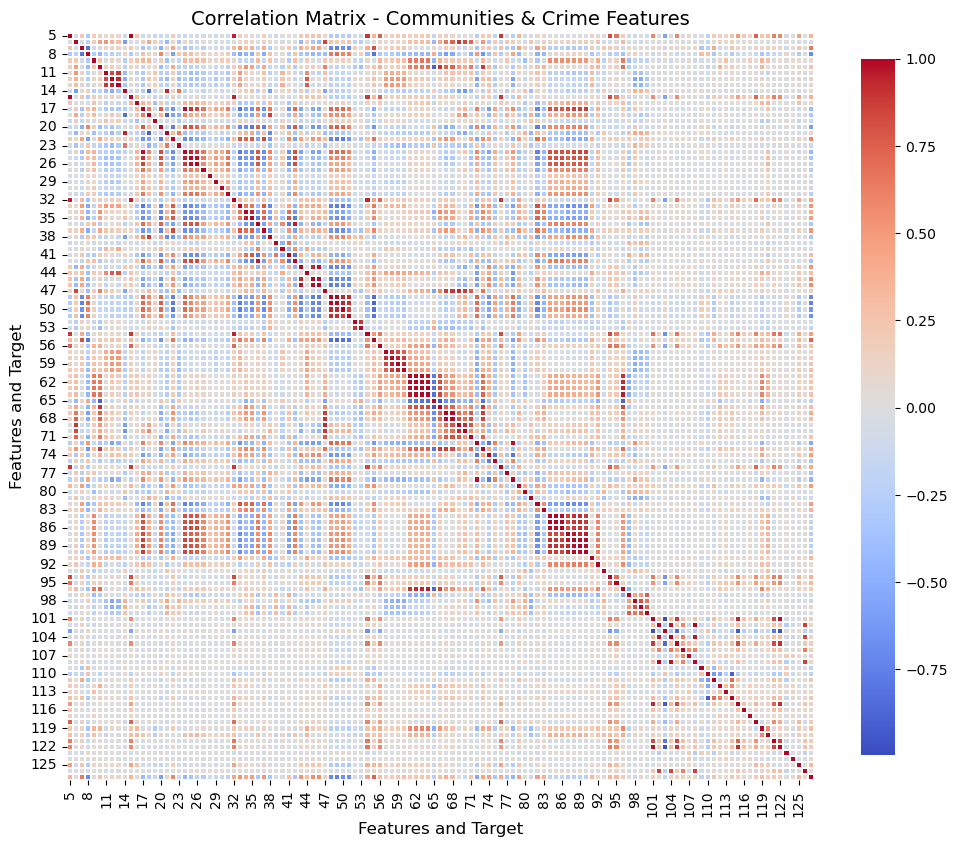

Correlation matrix plotted.


In [10]:
# Correlation matrix of features + target
# With 122 features a full matrix is crowded; we show a heatmap with aggregated view
train_imputed_df = pd.DataFrame(X_train, columns=feature_cols_comm)
train_imputed_df['target'] = y_train

corr_matrix = train_imputed_df.corr()

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',           
    annot=False,               
    fmt=".2f",
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": .8}
)
ax.set_title('Correlation Matrix - Communities & Crime Features', fontsize=14)
plt.tight_layout()
plt.xlabel('Features and Target', fontsize=12)
plt.ylabel('Features and Target', fontsize=12)
plt.show()
print('Correlation matrix plotted.')

### (d) Calculate the Coefficient of Variation CV

In [11]:
# CV = std / mean for each feature (computed on training set)
means = train_imputed_df[feature_cols_comm].mean()
stds  = train_imputed_df[feature_cols_comm].std()

# Avoid division by zero
cv_series = (stds / means.abs()).replace([np.inf, -np.inf], np.nan).dropna()
cv_series = cv_series.sort_values(ascending=False)

print('Top 20 features by CV:')
print(cv_series.head(20).to_string())

Top 20 features by CV:
95     4.292923
94     3.470952
54     3.058964
56     2.926635
125    2.552946
32     2.342443
5      2.241105
15     2.038461
76     1.968467
118    1.645408
10     1.612091
66     1.456618
7      1.428885
120    1.397110
9      1.359100
61     1.288287
62     1.286184
64     1.270476
63     1.265579
73     1.132926


The highest-CV features are those with the greatest relative spread compared with their mean. That does **not** automatically mean they are the most predictive features, but it does identify variables that vary substantially across communities. These are good candidates for exploratory plots, not for final feature selection by themselves.

### (e) Scatter plots and box plots for highest CV features

Selecting top 11 features by CV
Selected features: [95, 94, 54, 56, 125, 32, 5, 15, 76, 118, 10]


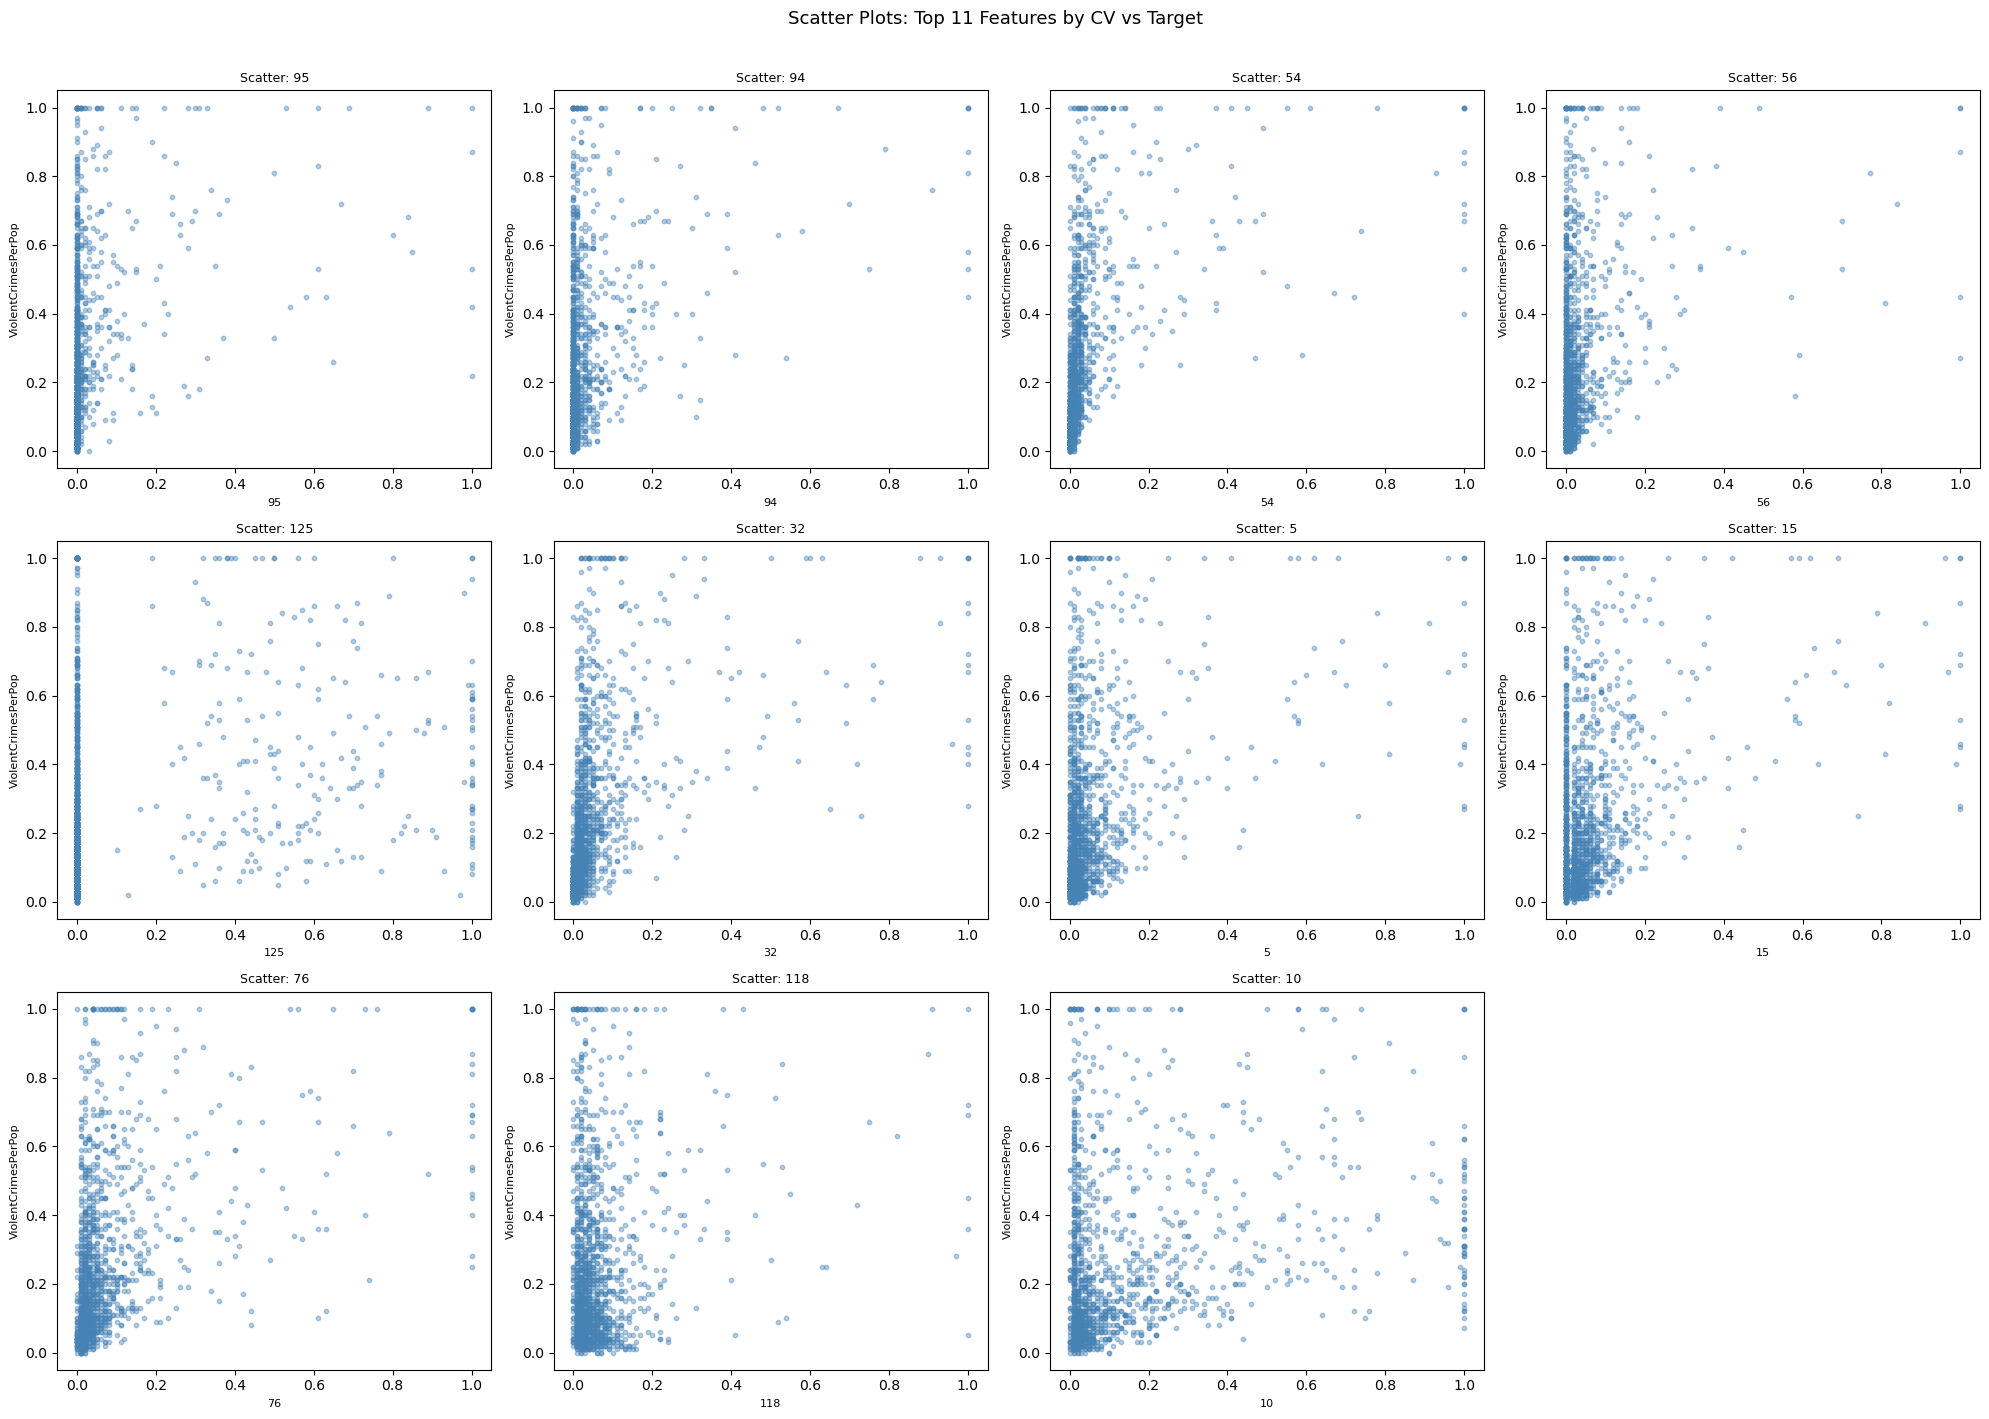

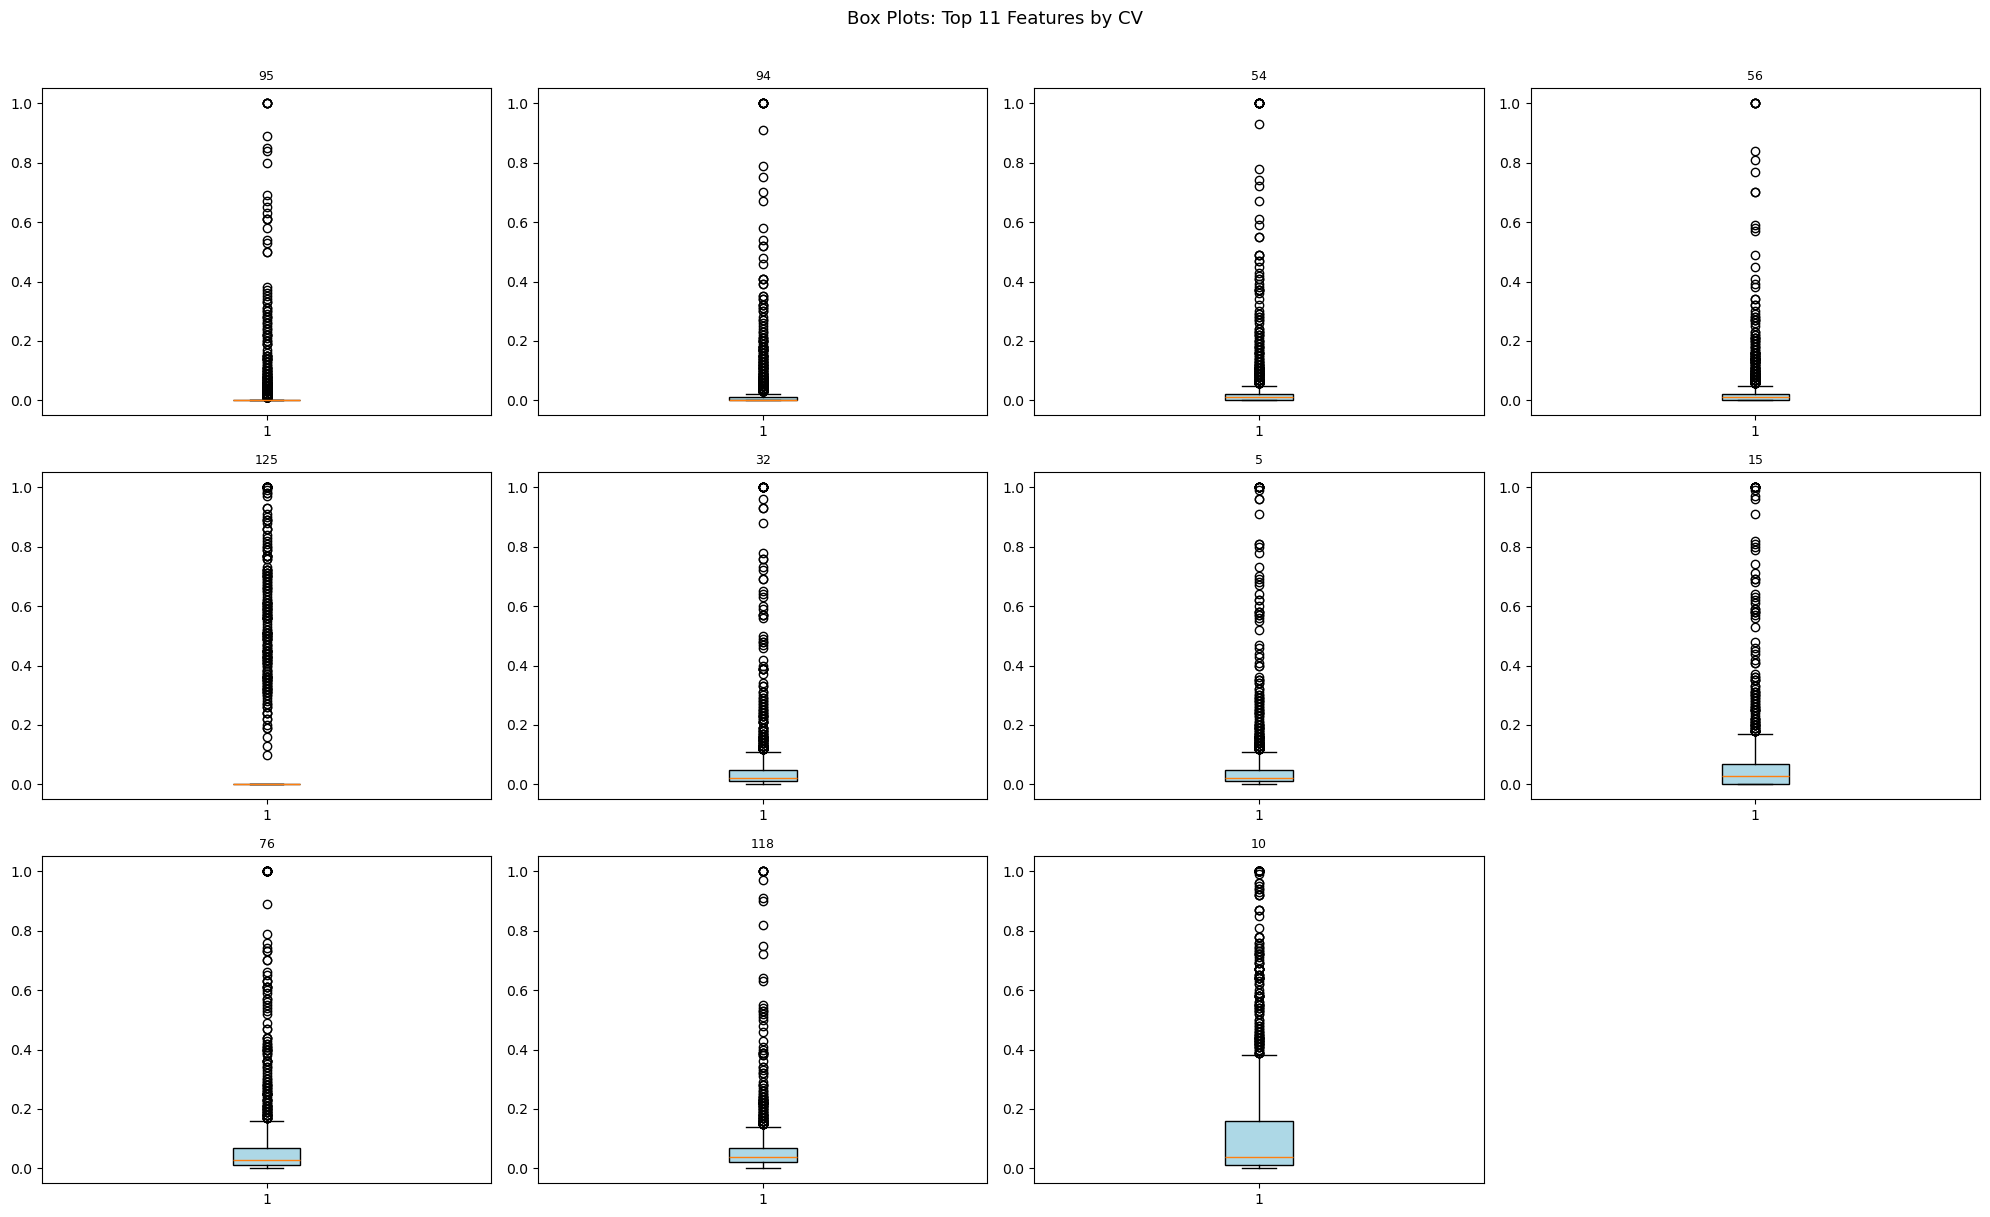

In [12]:
# Pick floor(sqrt(128)) = 11 features with highest CV
import math
k = math.floor(math.sqrt(128))
print(f'Selecting top {k} features by CV')

top_k_features = cv_series.index[:k].tolist()
print('Selected features:', top_k_features)

# Scatter plots: each feature vs target
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for i, feat in enumerate(top_k_features):
    axes[i].scatter(train_imputed_df[feat], y_train, alpha=0.4, s=10, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('ViolentCrimesPerPop', fontsize=8)
    axes[i].set_title(f'Scatter: {feat}', fontsize=9)
# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle(f'Scatter Plots: Top {k} Features by CV vs Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Box plots
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, feat in enumerate(top_k_features):
    axes[i].boxplot(train_imputed_df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{feat}', fontsize=9)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle(f'Box Plots: Top {k} Features by CV', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The scatter plots can reveal visible trends, outliers, or heavy clustering, but they are not enough to judge statistical significance on their own. In a high-dimensional, correlated dataset like this one, some features may look noisy in isolation yet still contribute to a multivariate model through interactions with other predictors.

### (f) Fit a linear model

In [13]:
# Ordinary Least Squares
# Standardizing the predictors makes the fit numerically stable on this highly collinear dataset.
ols_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

ols_pipe.fit(X_train, y_train)

y_pred_lr = ols_pipe.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f'Linear Model (OLS with standardized predictors)')
print(f'  Test MSE:  {mse_lr:.6f}')
print(f'  Test RMSE: {rmse_lr:.6f}')


Linear Model (OLS with standardized predictors)
  Test MSE:  0.018142
  Test RMSE: 0.134692


Ordinary least squares provides the baseline error for comparison. The test RMSE is modest, but the model is vulnerable to multicollinearity and overfitting because the number of predictors is large relative to the information each one contributes. Regularization should therefore help.

### (g) Fit a ridge regression model

In [14]:
# Ridge with CV to select lambda
alphas = np.logspace(-4, 4, 100)
ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print(f'Ridge Regression')
print(f'  Best lambda (alpha): {ridge.alpha_:.6f}')
print(f'  Test MSE:            {mse_ridge:.6f}')
print(f'  Test RMSE:           {rmse_ridge:.6f}')

Ridge Regression
  Best lambda (alpha): 2.310130
  Test MSE:            0.017600
  Test RMSE:           0.132664


Ridge gives a slightly lower test error than OLS, which is consistent with the strong correlation structure in the predictors. Shrinkage stabilizes the coefficients without forcing many of them exactly to zero, so it is a good fit when many variables are weakly informative but still useful together.

### (h) Fit a LASSO model

In [15]:
# --- LASSO on raw (already normalized) features ---
lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

# Variables selected (non-zero coefficients)
selected_mask = lasso.coef_ != 0
selected_features = np.array(feature_cols_comm)[selected_mask]

print(f'LASSO (raw features)')
print(f'  Best lambda: {lasso.alpha_:.6f}')
print(f'  Test MSE:    {mse_lasso:.6f}')
print(f'  Test RMSE:   {rmse_lasso:.6f}')
print(f'  Variables selected ({len(selected_features)}): {list(selected_features)}')

print('\n' + '='*60)

# --- LASSO on standardized features ---
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

lasso_std = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_std.fit(X_train_std, y_train)

y_pred_lasso_std = lasso_std.predict(X_test_std)
mse_lasso_std = mean_squared_error(y_test, y_pred_lasso_std)
rmse_lasso_std = np.sqrt(mse_lasso_std)

selected_mask_std = lasso_std.coef_ != 0
selected_features_std = np.array(feature_cols_comm)[selected_mask_std]

print(f'LASSO (standardized features)')
print(f'  Best lambda: {lasso_std.alpha_:.6f}')
print(f'  Test MSE:    {mse_lasso_std:.6f}')
print(f'  Test RMSE:   {rmse_lasso_std:.6f}')
print(f'  Variables selected ({len(selected_features_std)}): {list(selected_features_std)}')

print('\n--- Comparison ---')
print(f'  LASSO (raw) RMSE:  {rmse_lasso:.6f}')
print(f'  LASSO (std) RMSE:  {rmse_lasso_std:.6f}')
print(f'  Note: Features in this dataset are already normalized (0-1),\n'
      f'  so standardization makes a modest difference in selected lambda and test error.')

LASSO (raw features)
  Best lambda: 0.000116
  Test MSE:    0.017758
  Test RMSE:   0.133260
  Variables selected (75): [np.int32(7), np.int32(9), np.int32(11), np.int32(12), np.int32(16), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(33), np.int32(34), np.int32(38), np.int32(39), np.int32(41), np.int32(43), np.int32(44), np.int32(45), np.int32(49), np.int32(50), np.int32(51), np.int32(53), np.int32(54), np.int32(55), np.int32(56), np.int32(60), np.int32(64), np.int32(66), np.int32(68), np.int32(69), np.int32(72), np.int32(73), np.int32(74), np.int32(75), np.int32(76), np.int32(77), np.int32(79), np.int32(80), np.int32(81), np.int32(82), np.int32(83), np.int32(84), np.int32(87), np.int32(90), np.int32(91), np.int32(92), np.int32(93), np.int32(94), np.int32(95), np.int32(96), np.int32(97), np.int32(99), np.int32(104), np.int32(105), np.int32(107), np.int32(1

LASSO produces a sparse model, but the improvement over OLS is small here because the dataset is already normalized and highly correlated. The raw and standardized versions have nearly the same RMSE, which is expected when the predictors are already on a comparable scale. The selected variables are still useful for interpretation, but the near-tie in error suggests sparsity does not come at a major accuracy gain in this case.

### (i) Fit a PCR model

Best number of principal components M = 60


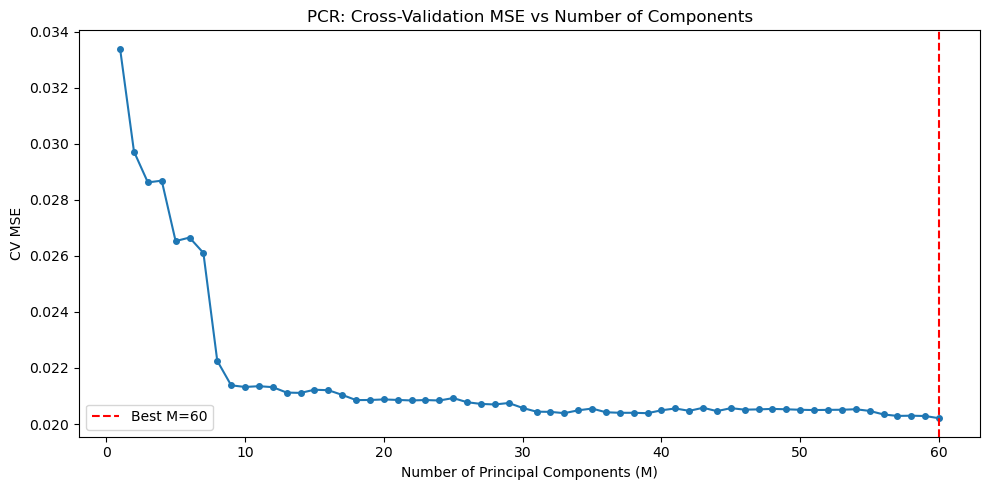

PCR Model
  Best M:    60
  Test MSE:  0.018400
  Test RMSE: 0.135647


In [16]:
# PCR: PCA + Linear Regression, select number of components by CV
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_features = X_train.shape[1]

# Search over a range of M (number of components)
M_values = list(range(1, min(n_features, 60) + 1))
cv_mse = []

for M in M_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=M)),
        ('lr', LinearRegression())
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf,
                             scoring='neg_mean_squared_error')
    cv_mse.append(-scores.mean())

best_M = M_values[np.argmin(cv_mse)]
print(f'Best number of principal components M = {best_M}')

# Plot CV MSE vs M
plt.figure(figsize=(10, 5))
plt.plot(M_values, cv_mse, marker='o', markersize=4)
plt.axvline(x=best_M, color='red', linestyle='--', label=f'Best M={best_M}')
plt.xlabel('Number of Principal Components (M)')
plt.ylabel('CV MSE')
plt.title('PCR: Cross-Validation MSE vs Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

# Fit final PCR with best M
pcr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_M)),
    ('lr', LinearRegression())
])
pcr.fit(X_train, y_train)
y_pred_pcr = pcr.predict(X_test)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)
rmse_pcr = np.sqrt(mse_pcr)

print(f'PCR Model')
print(f'  Best M:    {best_M}')
print(f'  Test MSE:  {mse_pcr:.6f}')
print(f'  Test RMSE: {rmse_pcr:.6f}')

PCR selected the largest number of components considered (`M = 60`), which suggests that compressing the predictors too aggressively would discard useful signal. Even so, PCR is still slightly worse than ridge and LASSO on this split, indicating that principal components are not capturing the response-relevant variation as efficiently as direct regularization.

### (j) Fit a boosting tree

Best XGBoost reg_alpha (L1): 1.0
XGBoost (L1-penalized Gradient Boosting)
  Best reg_alpha: 1.0
  Test MSE:       0.016288
  Test RMSE:      0.127624


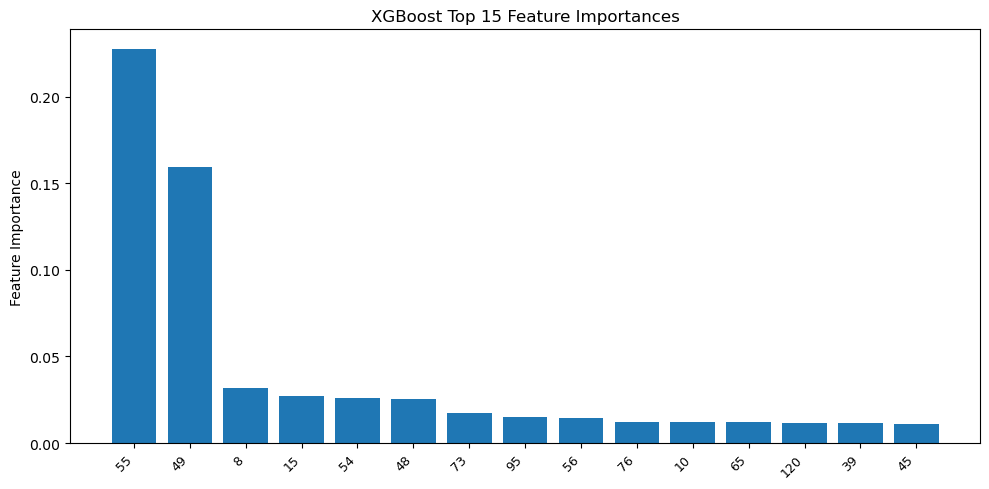

In [17]:
# L1-penalized gradient boosting tree using XGBoost
# alpha is the L1 regularization term in XGBoost (reg_alpha)

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Cross-validate to find best alpha (L1 regularization)
alpha_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42,
    verbosity=0,
    objective='reg:squarederror'
)

param_grid = {'reg_alpha': alpha_values}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

best_alpha_xgb = grid_search.best_params_['reg_alpha']
print(f'Best XGBoost reg_alpha (L1): {best_alpha_xgb}')

# Fit final model
xgb_best = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    reg_alpha=best_alpha_xgb,
    random_state=42,
    verbosity=0,
    objective='reg:squarederror'
)

xgb_best.fit(X_train, y_train)

y_pred_xgb = xgb_best.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print('XGBoost (L1-penalized Gradient Boosting)')
print(f'  Best reg_alpha: {best_alpha_xgb}')
print(f'  Test MSE:       {mse_xgb:.6f}')
print(f'  Test RMSE:      {rmse_xgb:.6f}')

# Feature importance
importances = xgb_best.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[top_idx])
plt.xticks(range(15), np.array(feature_cols_comm)[top_idx], rotation=45, ha='right', fontsize=9)
plt.ylabel('Feature Importance')
plt.title('XGBoost Top 15 Feature Importances')
plt.tight_layout()
plt.show()

XGBoost achieves the best test RMSE among the models tried. That result is plausible because boosting can capture nonlinear effects and interactions that linear models miss. The selected `reg_alpha` also shows that a modest amount of L1 regularization is enough to control model complexity without hurting predictive performance.

### Summary of Test Errors (Question 2)

In [18]:
print('='*50)
print('Model Comparison - Test RMSE')
print('='*50)
try:
    results = {
        'Linear Regression (OLS)': rmse_lr,
        'Ridge Regression':        rmse_ridge,
        'LASSO (raw)':             rmse_lasso,
        'LASSO (standardized)':    rmse_lasso_std,
        'PCR':                     rmse_pcr,
    }
  
    results['XGBoost (L1-penalized)'] = rmse_xgb


    for name, rmse in sorted(results.items(), key=lambda x: x[1]):
        print(f'  {name:<35}: RMSE = {rmse:.6f}')
except Exception as e:
    print(f'Some models not yet run: {e}')

Model Comparison - Test RMSE
  XGBoost (L1-penalized)             : RMSE = 0.127624
  Ridge Regression                   : RMSE = 0.132664
  LASSO (raw)                        : RMSE = 0.133260
  LASSO (standardized)               : RMSE = 0.133437
  Linear Regression (OLS)            : RMSE = 0.134692
  PCR                                : RMSE = 0.135647


The final ranking shows a clear advantage for boosting, followed by ridge and LASSO, with OLS and PCR slightly behind. The gap is not huge, but it is consistent enough to suggest that the regression task benefits from regularization and a nonlinear model. For interpretability, ridge and LASSO remain the most practical linear choices; for raw predictive accuracy, XGBoost is the strongest option.